# Task-03: Sentiment Analysis and Visualization of Social Media Data

## Introduction

Social media platforms contain a large amount of user-generated content that reflects people's opinions and attitudes toward different topics, products, and brands. Sentiment analysis helps identify whether these opinions are Positive, Negative, Neutral, or Irrelevant.

In this task, the Twitter social media dataset provided by Prodigy InfoTech is analyzed using Python. The data is cleaned and explored, and visualizations are created to understand the overall sentiment distribution and sentiment patterns across different entities or topics.

##Objectives
* To analyze sentiment patterns in Twitter social media data.
* To clean and preprocess the dataset for analysis.
* To identify the distribution of Positive, Negative, Neutral, and Irrelevant sentiments.
* To visualize the sentiment distribution using graphs.
* To analyze sentiment patterns across different entities or topics.
* To identify entities with higher positive or negative sentiment.
* To gain insights into public opinion toward different topics or brands.


Import libraries


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load the Dataset

In [21]:
df = pd.read_csv("/content/twitter_training.csv",header=None,names=["ID", "Entity", "Sentiment", "Tweet"])
print("Dataset loaded successfully!")

Dataset loaded successfully!


Check the dataset

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 74682
Columns: 4


In [22]:
df.head()

,ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


Check dataset information

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         74682 non-null  int64 
 1   Entity     74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Tweet      73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


Statistical Summary

In [24]:
df.describe()

,ID
count,74682.000000
mean,6432.586165
std,3740.427870
min,1.000000
25%,3195.000000
50%,6422.000000
75%,9601.000000
max,13200.000000


Check missing values

In [25]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
ID             0
Entity         0
Sentiment      0
Tweet        686
dtype: int64


Clean the data

In [26]:
# Remove duplicate rows
df = df.drop_duplicates().copy()

In [29]:
# Remove rows with missing values
df = df.dropna(
    subset=["Sentiment", "Tweet"]
).copy()


In [30]:
# Remove unnecessary spaces
df["Entity"] = df["Entity"].astype(str).str.strip()
df["Sentiment"] = df["Sentiment"].astype(str).str.strip()
df["Tweet"] = df["Tweet"].astype(str).str.strip()


In [31]:
print("Rows after cleaning:", df.shape[0])

Rows after cleaning: 71656


Check sentiment categories

In [33]:
print(df["Sentiment"].value_counts())

Sentiment
Negative      21698
Positive      19713
Neutral       17708
Irrelevant    12537
Name: count, dtype: int64


Main visualization


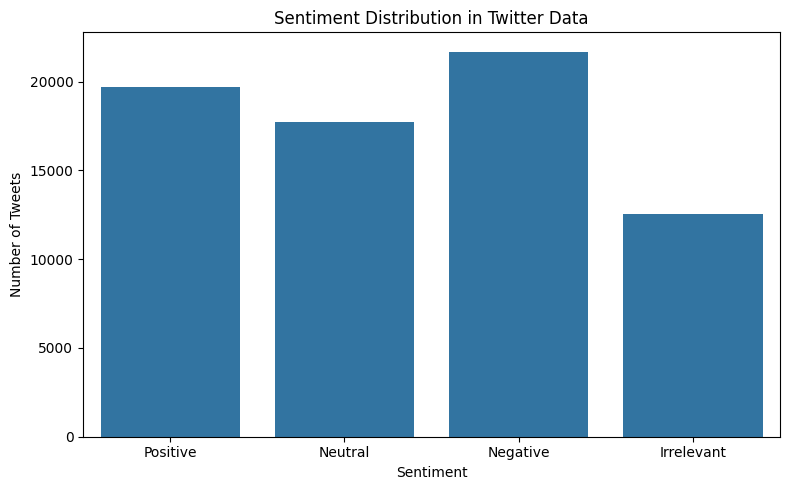

In [41]:
#Sentiment Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df,x="Sentiment")
plt.title("Sentiment Distribution in Twitter Data")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.tight_layout()
plt.show()

Sentiment percentage

In [42]:
sentiment_percentage = (df["Sentiment"].value_counts(normalize=True)* 100)
print(sentiment_percentage.round(2))

Sentiment
Negative      30.28
Positive      27.51
Neutral       24.71
Irrelevant    17.50
Name: proportion, dtype: float64


Top 10 entities

In [43]:
top_entities = (df["Entity"].value_counts().head(10))
print(top_entities)

Entity
TomClancysRainbowSix    2328
Verizon                 2319
MaddenNFL               2315
CallOfDuty              2314
Microsoft               2304
WorldOfCraft            2300
NBA2K                   2299
LeagueOfLegends         2296
TomClancysGhostRecon    2291
Facebook                2289
Name: count, dtype: int64


Sentiment by Entity

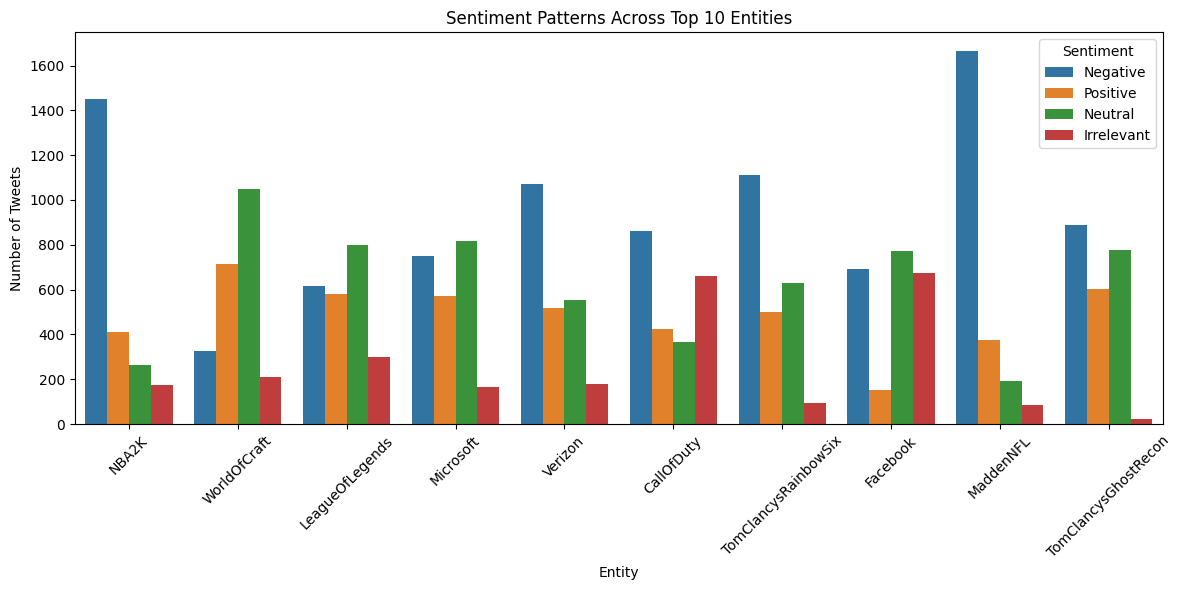

In [37]:
top_entity_names = top_entities.index
entity_data = df[df["Entity"].isin(top_entity_names)].copy()
plt.figure(figsize=(12, 6))
sns.countplot(data=entity_data,x="Entity",hue="Sentiment")
plt.title("Sentiment Patterns Across Top 10 Entities")
plt.xlabel("Entity")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Most positive entities

In [44]:
positive_entities = (df[df["Sentiment"] == "Positive"]["Entity"].value_counts().head(10))
print("Top entities with positive tweets:")
print(positive_entities)

Top entities with positive tweets:
Entity
AssassinsCreed               1382
Borderlands                   972
Cyberpunk2077                 902
PlayStation5(PS5)             890
RedDeadRedemption(RDR)        885
CallOfDutyBlackopsColdWar     817
Hearthstone                   806
Nvidia                        761
Xbox(Xseries)                 743
HomeDepot                     731
Name: count, dtype: int64


Most negative entities

In [45]:
negative_entities = (df[df["Sentiment"] == "Negative"]["Entity"].value_counts().head(10))
print("Top entities with negative tweets:")
print(negative_entities)

Top entities with negative tweets:
Entity
MaddenNFL               1665
NBA2K                   1450
FIFA                    1127
TomClancysRainbowSix    1110
Verizon                 1070
TomClancysGhostRecon     887
HomeDepot                871
CallOfDuty               861
johnson&johnson          809
Microsoft                748
Name: count, dtype: int64


## Key Observations

- The dataset contains Twitter posts associated with different entities.
- The sentiment categories include Positive, Negative, Neutral, and Irrelevant.
- The sentiment distribution shows the overall public attitude expressed in the tweets.
- Sentiment patterns vary across different entities.
- Some entities have a higher number of positive tweets, while others have more negative tweets.
- The analysis helps identify public opinion and sentiment trends toward different topics or brands.

## Conclusion

In this task, Twitter social media data was analyzed to understand sentiment patterns toward different entities.

The dataset was cleaned by removing duplicate and missing records. The distribution of Positive, Negative, Neutral, and Irrelevant sentiments was visualized using a count plot.

Sentiment patterns across the top 10 entities were also analyzed to identify differences in public opinion.

This task provided practical experience in data cleaning, exploratory data analysis, sentiment analysis, and data visualization using Python, Pandas, Matplotlib, and Seaborn.